# BOB - SynthSeg - SamSeg

In [ ]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns
import utils as ut 
import pingouin as pg

## Segmentation metrics

In [7]:
df_seg_synthseg = pd.read_csv("outputs/segmentation_metrics.csv")
df_seg_samseg = pd.read_csv("outputs/samseg/segmentation_metrics_samseg.csv")

df_seg_synthseg_wb = pd.read_csv("outputs/whole_brain_csf_metrics.csv")
df_seg_samseg_wb = pd.read_csv("outputs/samseg/whole_brain_csf_metrics_samseg.csv")

df_seg_synthseg = pd.concat([df_seg_synthseg, df_seg_synthseg_wb], ignore_index=True)
df_seg_samseg = pd.concat([df_seg_samseg, df_seg_samseg_wb], ignore_index=True)

In [8]:
names1 = set(df_seg_synthseg["name"].unique())
names2 = set(df_seg_samseg["name"].unique())

# Compare
common_names = names1 & names2
only_in_synthseg = names1 - names2
only_in_samseg  = names2 - names1          

print("Common:", common_names)
print("Only in SynthSeg:", only_in_synthseg)
print("Only in SamSeg:", only_in_samseg)


Common: {'Left-Cerebral-Cortex', 'Left-Putamen', 'whole_brain', 'Right-Lateral-Ventricle', 'whole_brain_minus_CSF', 'Left-Amygdala', 'Left-Thalamus', 'Right-Cerebellum-White-Matter', 'Left-Lateral-Ventricle', 'Right-Accumbens-area', 'Right-Cerebral-White-Matter', 'Right-Inf-Lat-Vent', 'Left-Caudate', 'Right-Cerebellum-Cortex', 'Left-Accumbens-area', 'CSF', 'Right-Thalamus', 'Left-Pallidum', 'Right-VentralDC', 'Left-Cerebellum-Cortex', '4th-Ventricle', 'Brain-Stem', '3rd-Ventricle', 'Right-Putamen', 'Left-Hippocampus', 'Left-Inf-Lat-Vent', 'Right-Cerebral-Cortex', 'Left-Cerebral-White-Matter', 'Left-Cerebellum-White-Matter', 'Right-Amygdala', 'Right-Pallidum', 'Right-Hippocampus', 'Right-Caudate'}
Only in SynthSeg: set()
Only in SamSeg: {'Optic-Chiasm', 'Left-vessel', 'WM-hypointensities', 'Right-choroid-plexus', 'whole_brain_minus_ALL', 'Left-VentralDC', 'Left-choroid-plexus', 'Right-vessel'}


Create base name- so that we can pool left/right together

In [13]:
df_seg_synthseg['base_name'] = df_seg_synthseg['name'].str.replace(r'^(Left-|Right-)', '', regex=True)
df_seg_synthseg['side'] = (df_seg_synthseg['name'].str.extract(r'^(Left|Right)-', expand=False).fillna('none'))

df_seg_samseg['base_name'] = df_seg_samseg['name'].str.replace(r'^(Left-|Right-)', '', regex=True)
df_seg_samseg['side'] = (df_seg_samseg['name'].str.extract(r'^(Left|Right)-', expand=False).fillna('none'))

common_names_base = {name.replace('Left-', '').replace('Right-', '') for name in common_names}

SamSeg 

In [ ]:
drop_structures = ['CSF', 'whole_brain']

combine_sides = True

if combine_sides:
    selected_common_name = common_names_base # for base names without Left/Right prefix
    selected_name = 'base_name'
else:
    selected_common_name = common_names # for all names
    selected_name = 'name'

base_list = [name for name in selected_common_name if name not in drop_structures]
base_list.sort()

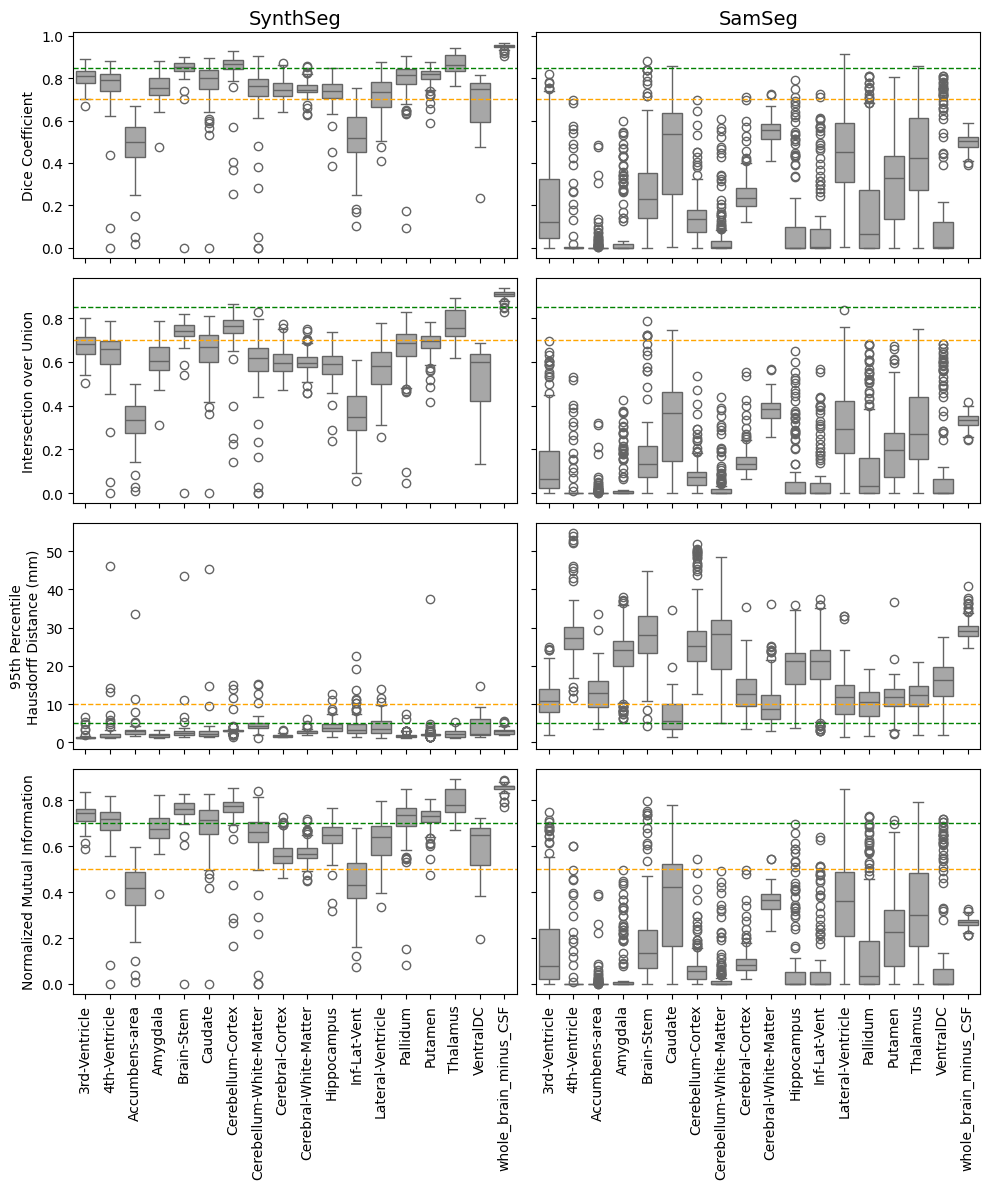

In [106]:
metrics_to_plot = ['Dice', 'IoU', 'HD95', 'NMI']

def assign_color(label_name):
    if 'Left' in label_name:
        return '#648FFF'
    elif 'Right' in label_name:
        return '#DC267F'
    elif 'whole_brain' in label_name:
        if combine_sides:
            return "#A7A7A7"
        else:
            return '#FFB000'
    else:
        return "#A7A7A7"
    
structure_palette = dict(zip(base_list, [assign_color(r) for r in base_list]))

ylabels = {
    'Dice': 'Dice Coefficient',
    'IoU':  'Intersection over Union',
    'HD95': '95th Percentile\nHausdorff Distance (mm)',
    'NMI':  'Normalized Mutual Information'
}

thresholds = {
    'Dice': [0.70, 0.85],
    'IoU':  [0.70, 0.85],
    'HD95': [10, 5],
    'NMI':  [0.50, 0.70]
}
thresh_colors = ['orange', 'green']

df_syn = df_seg_synthseg[df_seg_synthseg[selected_name].isin(base_list)].copy()
df_sam = df_seg_samseg[df_seg_samseg[selected_name].isin(base_list)].copy()

# plot
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 12), sharey='row', sharex=True)
for i, metric in enumerate(metrics_to_plot):
    # left: SynthSeg
    axL = axes[i, 0]
    sns.boxplot(
        data=df_syn[df_syn['metric'] == metric],
        x=selected_name, y='value', order=base_list,
        hue=selected_name,legend=False,
        palette=structure_palette, ax=axL
    )
    if i == 0:
        axL.set_title(f"SynthSeg", fontsize=14)
    axL.set_xlabel("")
    axL.set_ylabel(ylabels[metric])
    axL.tick_params(axis='x', rotation=90)
    if metric in thresholds:
        for t, c in zip(thresholds[metric], thresh_colors):
            axL.axhline(t, linestyle='--', color=c, linewidth=1)

    # right: SamSeg
    axR = axes[i, 1]
    sns.boxplot(
        data=df_sam[df_sam['metric'] == metric],
        x=selected_name, y='value', order=base_list,
        hue=selected_name,legend=False,
        palette=structure_palette, ax=axR
    )
    if i == 0:
        axR.set_title(f"SamSeg", fontsize=14)
    axR.set_xlabel("")
    axR.set_ylabel("")
    axR.tick_params(axis='x', rotation=90)
    if metric in thresholds:
        for t, c in zip(thresholds[metric], thresh_colors):
            axR.axhline(t, linestyle='--', color=c, linewidth=1)

plt.tight_layout()
plt.show()

## Volume

In [ ]:
df_volumes = pd.read_csv('outputs/segmentation_volumes.csv')
# only keep the volumes (not other metrics)
df_volumes = df_volumes[df_volumes['metric'].isin(['volume_BOB', 'volume_SynthSeg'])]

# load Samseg volumes
df_volumes_samseg = pd.read_csv('outputs/samseg/segmentation_volumes_samseg.csv')
df_volumes_samseg['name'] = (
    df_volumes_samseg['name']
      .str.replace(".nii", "")
)
df_volumes_samseg = df_volumes_samseg[df_volumes_samseg['metric'].isin(['volume_Samseg'])]

# combine all volumes into one dataframe
df_volumes_all = pd.concat([df_volumes, df_volumes_samseg], ignore_index=True)
df_volumes_all.sort_values(by=['participant_id', 'session_id', 'label', 'metric'], inplace=True)

df_volumes_all.head()

,participant_id,session_id,label,name,metric,value
1366,sub-116056,ses-3mo,2.0,Left-Cerebral-White-Matter,volume_BOB,147515.0
5389,sub-116056,ses-3mo,2.0,Left-Cerebral-White-Matter,volume_Samseg,271346.0
1367,sub-116056,ses-3mo,2.0,Left-Cerebral-White-Matter,volume_SynthSeg,140019.0
1224,sub-116056,ses-3mo,3.0,Left-Cerebral-Cortex,volume_BOB,146600.0
5375,sub-116056,ses-3mo,3.0,Left-Cerebral-Cortex,volume_Samseg,218110.0


In [48]:
df_volumes_wide = df_volumes_all.pivot_table(
    index=['participant_id', 'session_id', 'name'],
    columns='metric',
    values='value'
).reset_index()

# base_name and side to pool left and right
df_volumes_wide['base_name'] = df_volumes_wide['name'].str.replace(r'^(Left-|Right-)', '', regex=True)
df_volumes_wide['side'] = (df_volumes_wide['name'].str.extract(r'^(Left|Right)-', expand=False).fillna('none'))

df_volumes_wide.head()

metric,participant_id,session_id,name,volume_BOB,volume_Samseg,volume_SynthSeg,base_name,side
0,sub-116056,ses-3mo,3rd-Ventricle,897.0,418.0,700.0,3rd-Ventricle,none
1,sub-116056,ses-3mo,4th-Ventricle,603.0,677.0,527.0,4th-Ventricle,none
2,sub-116056,ses-3mo,Brain-Stem,11435.0,16713.0,11614.0,Brain-Stem,none
3,sub-116056,ses-3mo,Left-Accumbens-area,330.0,474.0,433.0,Accumbens-area,Left
4,sub-116056,ses-3mo,Left-Amygdala,708.0,1875.0,1091.0,Amygdala,Left


In [102]:
drop_structures = ['CSF', 'whole_brain']

combine_sides = True

if combine_sides:
    selected_common_name = common_names_base # for base names without Left/Right prefix
    selected_name = 'base_name'
else:
    selected_common_name = common_names # for all names
    selected_name = 'name'

base_list = [name for name in selected_common_name if name not in drop_structures]
base_list.sort()

In [103]:
parameter = 'volume'

methods = [f'{parameter}_BOB', f'{parameter}_SynthSeg', f'{parameter}_Samseg']  
pair_labels = [('BOB','SynthSeg'), ('BOB','Samseg'), ('SynthSeg','Samseg')]

if parameter == 'volume':
    decimal_places = 0
else:
    decimal_places = 2

stats_list = []

for label in base_list:
    sub = df_volumes_wide[df_volumes_wide[selected_name] == label].copy()
    if sub.empty:
        continue

    # keep only rows where ALL three methods are available (paired design)
    sub = sub.dropna(subset=methods)
    if sub.empty:
        continue

    # subject = participant_id + session_id (ensures correct pairing across methods)
    sub['subject'] = sub['participant_id'].astype(str) + '-' + sub['session_id'].astype(str)

    # descriptive stats
    bob      = sub[f'{parameter}_BOB']
    samseg   = sub[f'{parameter}_Samseg']
    synthseg = sub[f'{parameter}_SynthSeg']

    # long format for rm-ANOVA
    df_long = sub.melt(
        id_vars=['subject'],
        value_vars=methods,
        var_name='method', value_name='parameter'
    )

    # rm-ANOVA
    aov = pg.rm_anova(dv='parameter', within='method', subject='subject',
                      data=df_long, detailed=True)

    # post-hoc (paired t-tests with Holm correction)
    posthoc = pg.pairwise_tests(dv='parameter', within='method', subject='subject',
                                 data=df_long, padjust='holm', effsize='cohen')

    # pick Greenhouse–Geisser corrected p if available, else uncorrected
    p_anova = aov['p-gg-corr'].iloc[0] if 'p-gg-corr' in aov.columns else aov['p-unc'].iloc[0]

    row = {
        'name': label,
        'BOB': f"{bob.mean():.{decimal_places}f} ± {bob.std(ddof=1):.{decimal_places}f}",
        'SynthSeg': f"{synthseg.mean():.{decimal_places}f} ± {synthseg.std(ddof=1):.{decimal_places}f}",
        'SamSeg': f"{samseg.mean():.{decimal_places}f} ± {samseg.std(ddof=1):.{decimal_places}f}",
        'n': sub['subject'].nunique(),
        'ANOVA p-val': f"{p_anova:.3f}",
    }

    ph = posthoc[['A','B','p-corr','cohen']]

    # “Explode” posthoc into wide columns per pair
    for A, B in pair_labels:
        r = ph[(ph['A'] == f'{parameter}_{A}') & (ph['B'] == f'{parameter}_{B}')]
        sign = +1
        if r.empty:
            r = ph[(ph['A'] == f'{parameter}_{B}') & (ph['B'] == f'{parameter}_{A}')]
            sign = -1  # invert effect so it aligns with A-B direction
        if not r.empty:
            row[f'{A}-{B} p-val']   = f"{float(r['p-corr'].iloc[0]):.3f}"
            row[f'{A}-{B} effect']  = f"{float(r['cohen'].iloc[0]) * sign:.3f}"
        else:
            row[f'{A}-{B} p-val']   = np.nan
            row[f'{A}-{B} effect']  = np.nan

    stats_list.append(row)

df_stats_vol = pd.DataFrame(stats_list)
df_stats_vol


,name,BOB,SynthSeg,SamSeg,n,ANOVA p-val,BOB-SynthSeg p-val,BOB-SynthSeg effect,BOB-Samseg p-val,BOB-Samseg effect,SynthSeg-Samseg p-val,SynthSeg-Samseg effect
0,3rd-Ventricle,641 ± 142,544 ± 178,1487 ± 652,70,0.000,0.000,0.600,0.000,-1.793,0.000,-1.973
1,4th-Ventricle,760 ± 168,567 ± 208,2081 ± 906,70,0.000,0.000,1.021,0.000,-2.028,0.000,-2.304
2,Accumbens-area,318 ± 104,543 ± 120,433 ± 97,71,0.000,0.000,-2.157,0.000,-1.214,0.000,1.117
3,Amygdala,787 ± 181,1052 ± 215,1583 ± 315,71,0.000,0.000,-1.376,0.000,-3.165,0.000,-2.022
4,Brain-Stem,9813 ± 1381,11060 ± 2448,15407 ± 3382,71,0.000,0.000,-0.627,0.000,-2.166,0.000,-1.473
5,Caudate,2684 ± 612,2345 ± 592,2371 ± 394,71,0.000,0.000,0.567,0.000,0.620,0.530,-0.070
6,Cerebellum-Cortex,28260 ± 7461,33518 ± 8962,46038 ± 10217,71,0.000,0.000,-0.643,0.000,-2.005,0.000,-1.323
7,Cerebellum-White-Matter,5963 ± 2369,4429 ± 1415,12354 ± 2293,71,0.000,0.000,0.791,0.000,-2.783,0.000,-4.237
8,Cerebral-Cortex,157105 ± 37962,183814 ± 27948,192862 ± 21864,71,0.000,0.000,-0.801,0.000,-1.157,0.000,-0.362
9,Cerebral-White-Matter,129062 ± 21484,119995 ± 18961,243125 ± 30659,71,0.000,0.000,0.450,0.000,-4.328,0.000,-4.835


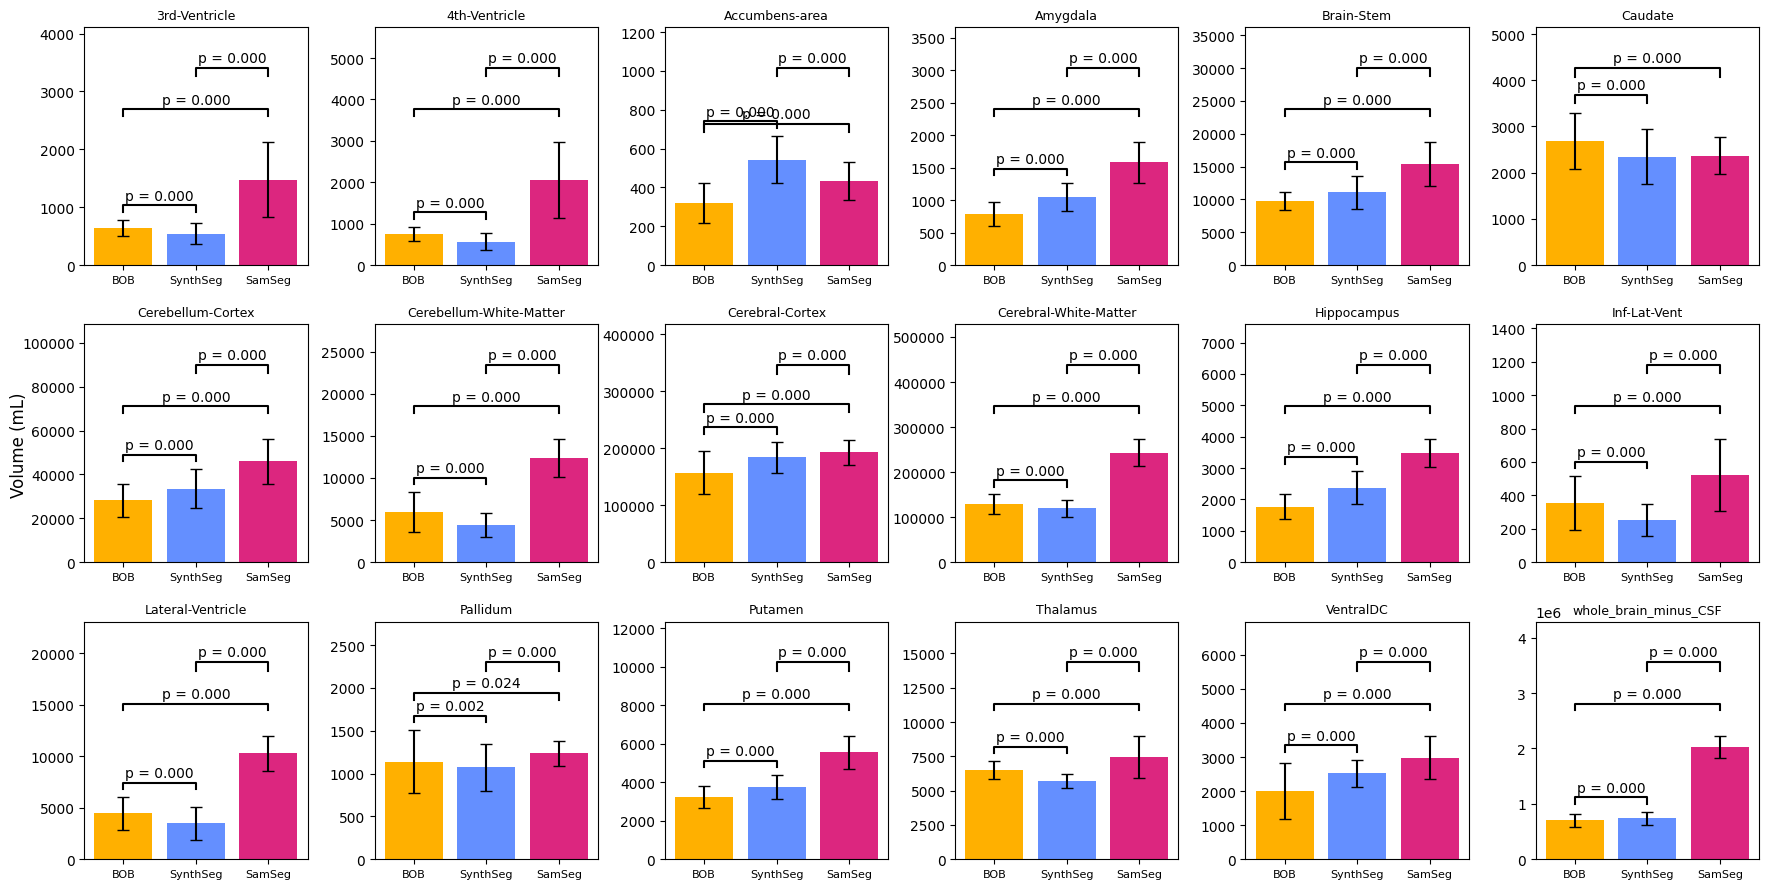

In [105]:
xticks = ['BOB', 'SynthSeg', 'SamSeg']

agg = df_volumes_wide.groupby(selected_name)[methods].agg(['mean', 'std'])

n_pairs = len(base_list)
ncols = 6
nrows = int(np.ceil(n_pairs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3), sharey=False)
axes = axes.flatten()

colors_seg = ['#FFB000', '#648FFF', '#DC267F' ]  

ALPHA = 0.05

for ax, label in zip(axes, base_list):
    if label not in agg.index:
        ax.axis('off')
        continue

    # pull means/stds for the three methods
    means = [agg.loc[label][(m, 'mean')] for m in methods]
    stds  = [agg.loc[label][(m, 'std')]  for m in methods]

    x = np.arange(len(methods))
    ax.bar(x, means, yerr=stds, capsize=4, color=colors_seg[:3])
    ax.set_xticks(x)
    ax.set_xticklabels(xticks, fontsize=8)
    ax.set_title(label, fontsize=9)

    # annotate pairwise p-values from df_stats_vol (wide format with per-pair columns)
    row = df_stats_vol.loc[df_stats_vol['name'] == label]
    if not row.empty:
        # three pairs: (0,1), (0,2), (1,2)
        pairs = [
            (0, 1, 'BOB-SynthSeg p-val'),
            (0, 2, 'BOB-Samseg p-val'),
            (1, 2, 'SynthSeg-Samseg p-val')
        ]
        # stack the brackets with different vertical offsets to avoid overlap
        dhs = [0.06, 0.20, 0.40]

        for (i, j, col), dh in zip(pairs, dhs):
            try:
                p = float(row[col].iloc[0])
            except Exception:
                p = np.nan
            if np.isfinite(p) and p < ALPHA:
                ut.barplot_annotate_brackets(
                    i, j,
                    f"p = {p:.3f}",
                    x, means, yerr=stds, dh=dh, ax=ax
                )

    # a little headroom
    ax.set_ylim([min(ax.get_ylim()), max(ax.get_ylim()) * 1.15])

# turn off any unused axes
for ax in axes[n_pairs:]:
    ax.axis('off')

fig.supylabel("Volume (mL)", fontsize=12)
plt.tight_layout()
plt.subplots_adjust(hspace=0.25, wspace=0.3)
plt.show()
